In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [ ]:
mnist= keras.datasets.mnist
(x_train,y_train),(x_test,y_test) = mnist.load_data()
x_train,x_test = x_train / 255.0, x_test / 255.0

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[2547])

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1265])

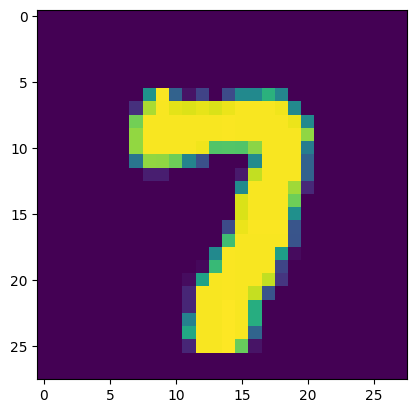

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(x_train[1225])

In [ ]:
x_train.shape

In [ ]:
y_train[1225]

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

In [ ]:
model.compile(optimizer = 'adam',
              loss='sparse_categorical_crossentropy',
              metrics = ['accuracy']
              )

In [ ]:
she=model.fit(x_train,y_train,validation_split = 0.2,epochs=12)

In [ ]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
y_pred[2512]

array([0.12164799, 0.08820724, 0.16396679, 0.06436522, 0.05822021,
       0.11134075, 0.13303785, 0.07954145, 0.09653937, 0.08313318],
      dtype=float32)

In [ ]:
import numpy as np
y_pred1 = np.argmax(y_pred,axis=1)
y_pred1[2512]

np.int64(2)

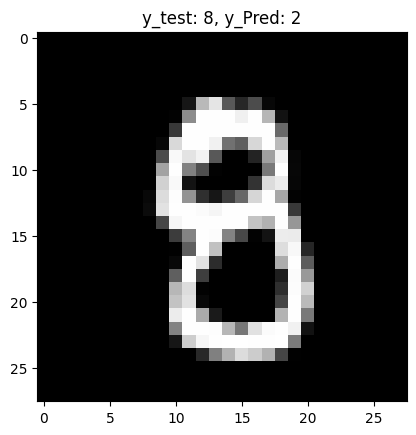

In [ ]:
import matplotlib.pyplot as plt
all= 2512
plt.imshow(x_test[all],cmap='gray')
plt.title(f"y_test: {y_test[all]}, y_Pred: {y_pred1[all]}")
plt.show()

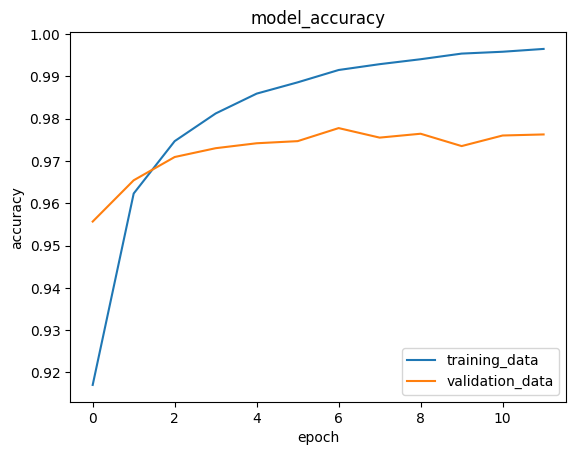

In [ ]:
plt.plot(she.history['accuracy'])
plt.plot(she.history['val_accuracy'])
plt.title('model_accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['training_data','validation_data'],loc='lower right')

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

In [ ]:
model.save("handwritten_digit_model.h5")
model = load_model("handwritten_digit_model.h5")

In [ ]:
img = cv2.imread("/content/2.jpeg", cv2.IMREAD_GRAYSCALE)

In [ ]:
img = cv2.resize(img, (28,28))

error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/resize.cpp:4208: error: (-215:Assertion failed) !ssize.empty() in function 'resize'


In [ ]:
img = 255 - img

In [ ]:
img = img / 255.0


In [ ]:
img_input = img.reshape(1,28,28,1)

In [ ]:
prediction = model.predict(img_input)
digit = np.argmax(prediction)

print("Predicted Digit:", digit)

In [ ]:
plt.imshow(img, cmap='gray')
plt.title(f"Prediction: {digit}")
plt.axis('off')
plt.show()

In [ ]:
model.save("mnist_model.h5")